## Imports and Filepaths

In [3]:
import ast
import pandas as pd
import numpy as np
import re
import tiktoken

import statsmodels.formula.api as smf

import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
# general
results_dir = "data/analysis/all_results/"
docs_dir = "data/analysis/gold_variants/"

# CBB
cbb_results_filepath = results_dir + "cbb_all_results.csv"
cbb_docs_filepath = docs_dir + "cbb_gold_variants.csv"

# NQ
nq_results_filepath = results_dir + "nq_all_results.csv"
nq_docs_filepath = docs_dir + "nq_gold_variants.csv"

# NM
nm_results_filepath = results_dir + "nm_all_results.csv"
nm_docs_filepath = docs_dir + "nm_gold_variants.csv"

## Loading and Preprocessing

In [5]:
# CBB 

# load the data
cbb_raw_results = pd.read_csv(cbb_results_filepath)
cbb_raw_docs = pd.read_csv(cbb_docs_filepath)

# drop baseline results
baseline_columns = [
    'Agent_V_tokens', 'Agent_N_tokens', 'Agent_T_tokens', 'Agent_G_tokens', 
    'Agent_V_bioscore', 'Agent_N_bioscore', 'Agent_T_bioscore', 'Agent_G_bioscore',
    'no_ctx_bioscore','sm_g_bioscore','md_g_bioscore', 'lg_g_bioscore','distractor_bioscore',
    'sm_g_tokens', 'md_g_tokens', 'lg_g_tokens', 'distractor_tokens'
]
cbb_raw_results.drop(columns=baseline_columns, inplace=True)

# change bioscore --> correctness (1 if bioscore >= 2/3, 0 else)
BIOSCORE_CORRECT_THRESHOLD = (2 / 3)
bioscore_cols = [c for c in cbb_raw_results.columns if c.endswith('_bioscore')]
for col in bioscore_cols:
    correct_col = col.replace('_bioscore', '_correct')
    cbb_raw_results[correct_col] = (cbb_raw_results[col] >= BIOSCORE_CORRECT_THRESHOLD).astype('uint8')
cbb_raw_results.drop(columns=bioscore_cols, inplace=True)

print(f"CBB raw results columns: {cbb_raw_results.columns}")
print(f"CBB raw docs columns: {cbb_raw_docs.columns}")

CBB raw results columns: Index(['model', 'task_id', 'sm_g@0.0_correct', 'sm_g@0.25_correct',
       'sm_g@0.5_correct', 'sm_g@0.75_correct', 'sm_g@1.0_correct',
       'md_g@0.0_correct', 'md_g@0.25_correct', 'md_g@0.5_correct',
       'md_g@0.75_correct', 'md_g@1.0_correct', 'lg_g@0.0_correct',
       'lg_g@0.25_correct', 'lg_g@0.5_correct', 'lg_g@0.75_correct',
       'lg_g@1.0_correct'],
      dtype='object')
CBB raw docs columns: Index(['task_id', 'answer', 'sm_g', 'md_g', 'lg_g', 'distractor_ctx'], dtype='object')


In [6]:
# NQ

# load the data
nq_raw_results = pd.read_csv(nq_results_filepath)
nq_raw_docs = pd.read_csv(nq_docs_filepath)

# drop baseline results
baseline_columns = [
    'gold_sentence_tokens', 'gold_paragraph_tokens', 'gold_section_tokens', 'gold_article_tokens', 'distractor_200_tokens',
    'no_ctx_subEM', 'sm_g_subEM', 'md_g_subEM', 'lg_g_subEM', 'distractor_200_subEM',
]
nq_raw_results.drop(columns=baseline_columns, inplace=True)

# change subEM --> correctness (1 if subEm == 1, 0 else)
subEM_cols = [c for c in nq_raw_results.columns if c.endswith('_subEM')]
for col in subEM_cols:
    correct_col = col.replace('_subEM', '_correct')
    nq_raw_results[correct_col] = (nq_raw_results[col]).astype('uint8')
nq_raw_results.drop(columns=subEM_cols, inplace=True)

# change sizes to uniform naming scheme
gold_size_naming = {"gold_sentence": "sm_g", "gold_paragraph": "md_g", "gold_section": "lg_g"}
nq_raw_docs = nq_raw_docs.rename(columns=gold_size_naming)

print(f"NQ raw results columns: {nq_raw_results.columns}")
print(f"NQ raw docs columns: {nq_raw_docs.columns}")

NQ raw results columns: Index(['model', 'task_id', 'sm_g@0.0_correct', 'sm_g@0.2_correct',
       'sm_g@0.4_correct', 'sm_g@0.6_correct', 'sm_g@0.8_correct',
       'sm_g@1.0_correct', 'md_g@0.0_correct', 'md_g@0.2_correct',
       'md_g@0.4_correct', 'md_g@0.6_correct', 'md_g@0.8_correct',
       'md_g@1.0_correct', 'lg_g@0.0_correct', 'lg_g@0.2_correct',
       'lg_g@0.4_correct', 'lg_g@0.6_correct', 'lg_g@0.8_correct',
       'lg_g@1.0_correct'],
      dtype='object')
NQ raw docs columns: Index(['task_id', 'answer', 'sm_g', 'md_g', 'lg_g', 'distractor_ctx'], dtype='object')


In [7]:
# NM

# load the data
nm_raw_results = pd.read_csv(nm_results_filepath)
nm_raw_docs = pd.read_csv(nm_docs_filepath)

# drop baseline results
baseline_columns = [
    'sm_g_tokens', 'md_g_tokens', 'lg_g_tokens', 'distractor_10_tokens', 'distractor_15_tokens', 'distractor_5_tokens',
    'no_ctx_math-verify', 'sm_g_math-verify', 'md_g_math-verify', 'lg_g_math-verify', 'distractor_5_math-verify',
]
nm_raw_results.drop(columns=baseline_columns, inplace=True)

# change math-verify --> correctness (1 if math-verify == 1, 0 else)
math_verify_cols = [c for c in nm_raw_results.columns if c.endswith('_math-verify')]
for col in math_verify_cols:
    correct_col = col.replace('_math-verify', '_correct')
    nm_raw_results[correct_col] = (nm_raw_results[col]).astype('uint8')
nm_raw_results.drop(columns=math_verify_cols, inplace=True)

print(f"NM raw results columns: {nm_raw_results.columns}")
print(f"NM raw docs columns: {nm_raw_docs.columns}")

NM raw results columns: Index(['model', 'task_id', 'sm_g@0.0_correct', 'sm_g@0.2_correct',
       'sm_g@0.4_correct', 'sm_g@0.6_correct', 'sm_g@0.8_correct',
       'sm_g@1.0_correct', 'md_g@0.0_correct', 'md_g@0.2_correct',
       'md_g@0.4_correct', 'md_g@0.6_correct', 'md_g@0.8_correct',
       'md_g@1.0_correct', 'lg_g@0.0_correct', 'lg_g@0.2_correct',
       'lg_g@0.4_correct', 'lg_g@0.6_correct', 'lg_g@0.8_correct',
       'lg_g@1.0_correct'],
      dtype='object')
NM raw docs columns: Index(['task_id', 'answer', 'sm_g', 'md_g', 'lg_g', 'distractor_ctx'], dtype='object')


## Feature Engineering

### Token Counts and Gold:Distractor Ratio

In [8]:
pd.set_option('display.float_format', '{:.2f}'.format)

In [9]:
# Helpers

def tokenize_tiktoken(text: str, model: str = "cl100k_base"):
    """
    Helper that tokenizes a string using tiktoken.
    """
    encoding = tiktoken.get_encoding(model)
    text = text or ""
    return encoding.encode(text)

def count_tokens_tiktoken(text: str, model: str = "cl100k_base") -> int:
    """
    Helper that returns token counts of a string using tiktoken.
    """
    return len(tokenize_tiktoken(text, model))

def add_token_and_ratio_cols(
    docs_df: pd.DataFrame, gold_cols = ("sm_g", "md_g", "lg_g"), distractor_col: str = "distractor_ctx", model_for_tok: str = "o200k_base"
) -> pd.DataFrame:
    """
    Adds *_tokens and *_ratio columns in place and returns the df.
    """
    # token counts
    for col in [*gold_cols, distractor_col]:
        tok_col = f"{col}_tokens"
        if tok_col not in docs_df.columns:
            docs_df[tok_col] = docs_df[col].apply(lambda x: count_tokens_tiktoken(str(x), model_for_tok)).astype("uint32")

    # sanity checks
    d_tok = f"{distractor_col}_tokens"
    assert (docs_df[d_tok] != 0).all(), "Zero token distractor rows detected, check preprocessing."
    assert (docs_df[[f"{g}_tokens" for g in gold_cols]] != 0).all().all(), "Zero token golds detected, check preprocessing."
    
    # ratios
    for g in gold_cols:
        g_tok = f"{g}_tokens"

        # gold : distractors
        docs_df[f"{g}_to_d_ratio"] = docs_df[g_tok] / docs_df[d_tok]

        # gold : all
        docs_df[f"{g}_to_all_ratio"] = docs_df[g_tok] / (docs_df[g_tok] + docs_df[d_tok])


    return docs_df

In [10]:
# CBB

cbb_docs_fe_ratio = add_token_and_ratio_cols(cbb_raw_docs.copy())

# threshold = cbb_docs_fe_ratio['lg_g_to_d_ratio'].quantile(98 / 100)
# cbb_docs_fe_ratio = cbb_docs_fe_ratio[cbb_docs_fe_ratio['lg_g_to_d_ratio'] <= threshold]

display(cbb_docs_fe_ratio.describe())

,task_id,sm_g_tokens,md_g_tokens,lg_g_tokens,distractor_ctx_tokens,sm_g_to_d_ratio,sm_g_to_all_ratio,md_g_to_d_ratio,md_g_to_all_ratio,lg_g_to_d_ratio,lg_g_to_all_ratio
count,250.00,250.00,250.00,250.00,250.00,250.00,250.00,250.00,250.00,250.00,250.00
mean,124.50,43.05,137.22,391.80,12493.55,0.01,0.01,0.02,0.02,0.06,0.05
std,72.31,71.06,72.86,1146.89,9465.14,0.01,0.01,0.03,0.03,0.12,0.07
min,0.00,9.00,84.00,96.00,545.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,62.25,17.00,101.00,133.25,7272.00,0.00,0.00,0.01,0.01,0.01,0.01
50%,124.50,32.50,125.00,188.00,11337.50,0.00,0.00,0.01,0.01,0.02,0.02
75%,186.75,46.75,147.75,288.00,16237.25,0.01,0.01,0.02,0.02,0.04,0.03
max,249.00,851.00,941.00,13627.00,61646.00,0.11,0.10,0.19,0.16,0.93,0.48


In [11]:
# NQ

nq_docs_fe_ratio = add_token_and_ratio_cols(nq_raw_docs.copy())
display(nq_docs_fe_ratio.describe())

,task_id,sm_g_tokens,md_g_tokens,lg_g_tokens,distractor_ctx_tokens,sm_g_to_d_ratio,sm_g_to_all_ratio,md_g_to_d_ratio,md_g_to_all_ratio,lg_g_to_d_ratio,lg_g_to_all_ratio
count,250.00,250.00,250.00,250.00,250.00,250.00,250.00,250.00,250.00,250.00,250.00
mean,124.50,38.68,110.49,630.21,23675.64,0.00,0.00,0.00,0.00,0.03,0.03
std,72.31,28.20,67.19,278.28,1144.45,0.00,0.00,0.00,0.00,0.01,0.01
min,0.00,4.00,5.00,111.00,20748.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,62.25,22.00,66.00,426.25,22997.75,0.00,0.00,0.00,0.00,0.02,0.02
50%,124.50,36.00,106.00,587.50,23616.50,0.00,0.00,0.00,0.00,0.02,0.02
75%,186.75,48.00,142.00,800.75,24232.25,0.00,0.00,0.01,0.01,0.03,0.03
max,249.00,317.00,443.00,1645.00,30982.00,0.01,0.01,0.02,0.02,0.07,0.07


In [12]:
# NM

nm_docs_fe_ratio = add_token_and_ratio_cols(nm_raw_docs.copy())
display(nm_docs_fe_ratio.describe())

,task_id,sm_g_tokens,md_g_tokens,lg_g_tokens,distractor_ctx_tokens,sm_g_to_d_ratio,sm_g_to_all_ratio,md_g_to_d_ratio,md_g_to_all_ratio,lg_g_to_d_ratio,lg_g_to_all_ratio
count,250.00,250.00,250.00,250.00,250.00,250.00,250.00,250.00,250.00,250.00,250.00
mean,124.50,98.26,451.03,4412.52,20315.66,0.01,0.00,0.02,0.02,0.22,0.18
std,72.31,52.85,309.80,1389.23,2853.66,0.00,0.00,0.02,0.02,0.09,0.06
min,0.00,23.00,54.00,969.00,11995.00,0.00,0.00,0.00,0.00,0.04,0.04
25%,62.25,65.00,234.50,3159.50,18633.50,0.00,0.00,0.01,0.01,0.15,0.13
50%,124.50,87.00,365.00,5182.50,20532.00,0.00,0.00,0.02,0.02,0.23,0.19
75%,186.75,113.00,560.50,5466.50,22358.75,0.01,0.01,0.03,0.03,0.28,0.22
max,249.00,466.00,1906.00,6681.00,25529.00,0.04,0.03,0.11,0.10,0.45,0.31


### Gold and Answer Token Repetition

In [13]:
# Helpers

def _to_list(ans):
    """
    Return a list of answer strings.
    """
    if ans is None or (isinstance(ans, float) and pd.isna(ans)):
        return []
    if isinstance(ans, list):
        return ans
    if isinstance(ans, str):
        s = ans.strip()
        try:
            parsed = ast.literal_eval(s)
            if isinstance(parsed, list):
                return parsed
        except (ValueError, SyntaxError):
            pass
        return [s]
    return [str(ans)] 

def tokenize_tiktoken(text: str, model: str = "cl100k_base"):
    """
    Tokenizes a string with tiktoken.
    """
    encoding = tiktoken.get_encoding(model)
    text = text or ""
    return encoding.encode(text)

def exact_mention_count(answer: str, context: str) -> int:
    """
    Counts (word bounded, exact, and case insensitive) matches of the answer string(s) in context.
    """
    ctx = context or ""
    total = 0
    for a in _to_list(answer):
        if not a:
            continue
        pat = re.compile(rf"(?<!\w){re.escape(a.strip())}(?!\w)", flags=re.I|re.S)
        total += len(pat.findall(ctx))
    return total

def answer_token_hits(answer: str, context: str, model: str = "cl100k_base"):
    """
    Returns token match count, unique match ratio, and repetition rate of answer tokens in context.
    """
    ans_tokens = set()
    for a in _to_list(answer):
        ans_tokens.update(tokenize_tiktoken(a, model))
    if not ans_tokens:
        return 0, 0.0, 0.0

    ctx_tokens = tokenize_tiktoken(context or "", model)
    hits = sum(tok in ans_tokens for tok in ctx_tokens)
    hit_ratio = len(ans_tokens.intersection(ctx_tokens)) / len(ans_tokens)
    redundancy = hits / len(ans_tokens)
    return hits, hit_ratio, redundancy

def add_answer_overlap_metrics(df: pd.DataFrame, doc_cols=("sm_g", "md_g", "lg_g", "distractor_ctx"), model: str = "cl100k_base"):
    """
    Adds answer repetition and overlap metrics:
    *_exact_mentions      Raw count of word-bounded, case-insensitive exact answer string matches.
    *_ans_tok_hits        Total context tokens identical to any answer token (duplicates included).
    *_ans_tok_hit_ratio   Unique token coverage: |answer tokens ∩ context| divided by |answer tokens|.
    *_ans_tok_redundancy  Repetition per answer token: ans_tok_hits divided by |answer tokens|.
    *_ans_tok_density     Proportion of the document made up of answer tokens: ans_tok_hits / context tokens.
    """
    for col in doc_cols:
        df[f"{col}_exact_mentions"] = df.apply(
            lambda r: exact_mention_count(r["answer"], r[col]),
            axis=1,
        )

        hits_tuple = df.apply(
            lambda r: answer_token_hits(r["answer"], r[col], model=model),
            axis=1, result_type="expand",
        )
        hits_tuple.columns = [f"{col}_ans_tok_hits", f"{col}_ans_tok_hit_ratio", f"{col}_ans_tok_redundancy"]
        df = pd.concat([df, hits_tuple], axis=1)

        # density = raw hits / gold‑passage length (clip to avoid div‑by‑zero)
        df[f"{col}_ans_tok_density"] = (df[f"{col}_ans_tok_hits"] / df[f"{col}_tokens"].clip(lower=1))

    return df

In [14]:
# CBB

cbb_docs_fe = add_answer_overlap_metrics(cbb_docs_fe_ratio)
display(cbb_docs_fe[[c for c in cbb_docs_fe.columns if c.endswith("_exact_mentions")]].describe())
display(cbb_docs_fe[[c for c in cbb_docs_fe.columns if c.endswith("_ans_tok_hits")]].describe())
display(cbb_docs_fe[[c for c in cbb_docs_fe.columns if c.endswith("_ans_tok_redundancy")]].describe())
# display(cbb_docs_fe[[c for c in cbb_docs_fe.columns if c.endswith("_ans_tok_hit_ratio")]].describe())
# display(cbb_docs_fe[[c for c in cbb_docs_fe.columns if c.endswith("_ans_tok_density")]].describe())

,sm_g_exact_mentions,md_g_exact_mentions,lg_g_exact_mentions,distractor_ctx_exact_mentions
count,250.00,250.00,250.00,250.00
mean,1.00,1.00,1.00,0.00
std,0.00,0.00,0.00,0.00
min,1.00,1.00,1.00,0.00
25%,1.00,1.00,1.00,0.00
50%,1.00,1.00,1.00,0.00
75%,1.00,1.00,1.00,0.00
max,1.00,1.00,1.00,0.00


,sm_g_ans_tok_hits,md_g_ans_tok_hits,lg_g_ans_tok_hits,distractor_ctx_ans_tok_hits
count,250.00,250.00,250.00,250.00
mean,43.51,56.46,95.64,1081.59
std,71.36,73.77,179.94,1038.86
min,9.00,12.00,14.00,10.00
25%,17.00,30.00,40.00,451.75
50%,32.00,45.00,56.00,797.00
75%,47.00,58.00,83.00,1419.00
max,855.00,887.00,1817.00,6868.00


,sm_g_ans_tok_redundancy,md_g_ans_tok_redundancy,lg_g_ans_tok_redundancy,distractor_ctx_ans_tok_redundancy
count,250.00,250.00,250.00,250.00
mean,1.17,1.69,2.86,34.79
std,0.43,0.46,3.69,30.08
min,1.00,1.14,1.14,0.77
25%,1.00,1.44,1.54,17.63
50%,1.07,1.60,2.05,30.02
75%,1.14,1.83,2.69,42.50
max,4.83,5.01,35.63,272.50


In [15]:
num_exact_mentions_all_one = len(cbb_docs_fe[(cbb_docs_fe['sm_g_exact_mentions'] == 1.0) & (cbb_docs_fe['md_g_exact_mentions'] == 1.0) & (cbb_docs_fe['lg_g_exact_mentions'] == 1.0)])

num_ans_tok_red_all_geq_two = len(cbb_docs_fe[(cbb_docs_fe['sm_g_ans_tok_redundancy'] >= 2.0) & (cbb_docs_fe['md_g_ans_tok_redundancy'] >= 2.0) & (cbb_docs_fe['lg_g_ans_tok_redundancy'] >= 2.0)])
num_ans_tok_red_sm_geq_two = len(cbb_docs_fe[(cbb_docs_fe['sm_g_ans_tok_redundancy'] >= 2.0)]['task_id'].unique())
num_ans_tok_red_md_geq_two = len(cbb_docs_fe[(cbb_docs_fe['md_g_ans_tok_redundancy'] >= 2.0)]['task_id'].unique())
num_ans_tok_red_lg_geq_two = len(cbb_docs_fe[(cbb_docs_fe['lg_g_ans_tok_redundancy'] >= 2.0)]['task_id'].unique())

num_ans_tok_red_all_leq_two = len(cbb_docs_fe[(cbb_docs_fe['sm_g_ans_tok_redundancy'] <= 2.0) & (cbb_docs_fe['md_g_ans_tok_redundancy'] <= 2.0) & (cbb_docs_fe['lg_g_ans_tok_redundancy'] <= 2.0)])
num_ans_tok_red_sm_leq_two = len(cbb_docs_fe[(cbb_docs_fe['sm_g_ans_tok_redundancy'] <= 2.0)]['task_id'].unique())
num_ans_tok_red_md_leq_two = len(cbb_docs_fe[(cbb_docs_fe['md_g_ans_tok_redundancy'] <= 2.0)]['task_id'].unique())
num_ans_tok_red_lg_leq_two = len(cbb_docs_fe[(cbb_docs_fe['lg_g_ans_tok_redundancy'] <= 2.0)]['task_id'].unique())

print(f"CBB questions with n exact mentions all == 1: {num_exact_mentions_all_one} out of 250")
print()
print(f"CBB questions with n ans tok redundancy all >= 2: {num_ans_tok_red_all_geq_two} out of 250")
print(f"CBB questions with n ans tok redundancy sm >= 2: {num_ans_tok_red_sm_geq_two} out of 250")
print(f"CBB questions with n ans tok redundancy md >= 2: {num_ans_tok_red_md_geq_two} out of 250")
print(f"CBB questions with n ans tok redundancy lg >= 2: {num_ans_tok_red_lg_geq_two} out of 250")
print()
print(f"CBB questions with n ans tok redundancy all <= 2: {num_ans_tok_red_all_leq_two} out of 250")
print(f"CBB questions with n ans tok redundancy sm <= 2: {num_ans_tok_red_sm_leq_two} out of 250")
print(f"CBB questions with n ans tok redundancy md <= 2: {num_ans_tok_red_md_leq_two} out of 250")
print(f"CBB questions with n ans tok redundancy lg <= 2: {num_ans_tok_red_lg_leq_two} out of 250")

CBB questions with n exact mentions all == 1: 250 out of 250

CBB questions with n ans tok redundancy all >= 2: 8 out of 250
CBB questions with n ans tok redundancy sm >= 2: 8 out of 250
CBB questions with n ans tok redundancy md >= 2: 36 out of 250
CBB questions with n ans tok redundancy lg >= 2: 139 out of 250

CBB questions with n ans tok redundancy all <= 2: 122 out of 250
CBB questions with n ans tok redundancy sm <= 2: 242 out of 250
CBB questions with n ans tok redundancy md <= 2: 223 out of 250
CBB questions with n ans tok redundancy lg <= 2: 122 out of 250


In [16]:
# NQ

nq_docs_fe = add_answer_overlap_metrics(nq_docs_fe_ratio)
display(nq_docs_fe[[c for c in nq_docs_fe.columns if c.endswith("_exact_mentions")]].describe())
display(nq_docs_fe[[c for c in nq_docs_fe.columns if c.endswith("_ans_tok_hits")]].describe())
display(nq_docs_fe[[c for c in nq_docs_fe.columns if c.endswith("_ans_tok_redundancy")]].describe())
# display(nq_docs_fe[[c for c in nq_docs_fe.columns if c.endswith("_ans_tok_hit_ratio")]].describe())
# display(nq_docs_fe[[c for c in nq_docs_fe.columns if c.endswith("_ans_tok_density")]].describe())

,sm_g_exact_mentions,md_g_exact_mentions,lg_g_exact_mentions,distractor_ctx_exact_mentions
count,250.00,250.00,250.00,250.00
mean,1.41,1.64,2.96,2.12
std,1.08,1.29,3.70,6.63
min,0.00,0.00,0.00,0.00
25%,1.00,1.00,1.00,0.00
50%,1.00,1.00,2.00,0.00
75%,2.00,2.00,3.00,2.00
max,7.00,8.00,33.00,77.00


,sm_g_ans_tok_hits,md_g_ans_tok_hits,lg_g_ans_tok_hits,distractor_ctx_ans_tok_hits
count,250.00,250.00,250.00,250.00
mean,5.29,8.71,26.44,595.56
std,5.91,9.91,33.09,862.78
min,0.00,0.00,0.00,0.00
25%,1.25,2.00,4.00,27.25
50%,4.00,5.00,14.50,194.50
75%,7.00,11.00,34.75,794.00
max,41.00,49.00,214.00,4824.00


,sm_g_ans_tok_redundancy,md_g_ans_tok_redundancy,lg_g_ans_tok_redundancy,distractor_ctx_ans_tok_redundancy
count,250.00,250.00,250.00,250.00
mean,0.74,1.11,3.23,65.34
std,0.58,0.88,2.98,79.56
min,0.00,0.00,0.00,0.00
25%,0.33,0.50,1.00,6.45
50%,0.67,0.97,2.58,37.31
75%,1.00,1.50,4.51,96.90
max,3.50,5.50,16.75,489.75


In [17]:
num_exact_mentions_all_one = len(nq_docs_fe[(nq_docs_fe['sm_g_exact_mentions'] == 1.0) & (nq_docs_fe['md_g_exact_mentions'] == 1.0) & (nq_docs_fe['lg_g_exact_mentions'] == 1.0)])

num_ans_tok_red_all_geq_two = len(nq_docs_fe[(nq_docs_fe['sm_g_ans_tok_redundancy'] >= 2.0) & (nq_docs_fe['md_g_ans_tok_redundancy'] >= 2.0) & (nq_docs_fe['lg_g_ans_tok_redundancy'] >= 2.0)])
num_ans_tok_red_sm_geq_two = len(nq_docs_fe[(nq_docs_fe['sm_g_ans_tok_redundancy'] >= 2.0)]['task_id'].unique())
num_ans_tok_red_md_geq_two = len(nq_docs_fe[(nq_docs_fe['md_g_ans_tok_redundancy'] >= 2.0)]['task_id'].unique())
num_ans_tok_red_lg_geq_two = len(nq_docs_fe[(nq_docs_fe['lg_g_ans_tok_redundancy'] >= 2.0)]['task_id'].unique())

num_ans_tok_red_all_leq_two = len(nq_docs_fe[(nq_docs_fe['sm_g_ans_tok_redundancy'] <= 2.0) & (nq_docs_fe['md_g_ans_tok_redundancy'] <= 2.0) & (nq_docs_fe['lg_g_ans_tok_redundancy'] <= 2.0)])
num_ans_tok_red_sm_leq_two = len(nq_docs_fe[(nq_docs_fe['sm_g_ans_tok_redundancy'] <= 2.0)]['task_id'].unique())
num_ans_tok_red_md_leq_two = len(nq_docs_fe[(nq_docs_fe['md_g_ans_tok_redundancy'] <= 2.0)]['task_id'].unique())
num_ans_tok_red_lg_leq_two = len(nq_docs_fe[(nq_docs_fe['lg_g_ans_tok_redundancy'] <= 2.0)]['task_id'].unique())

print(f"NQ questions with n exact mentions all == 1: {num_exact_mentions_all_one} out of 250")
print()
print(f"NQ questions with n ans tok redundancy all >= 2: {num_ans_tok_red_all_geq_two} out of 250")
print(f"NQ questions with n ans tok redundancy sm >= 2: {num_ans_tok_red_sm_geq_two} out of 250")
print(f"NQ questions with n ans tok redundancy md >= 2: {num_ans_tok_red_md_geq_two} out of 250")
print(f"NQ questions with n ans tok redundancy lg >= 2: {num_ans_tok_red_lg_geq_two} out of 250")
print()
print(f"NQ questions with n ans tok redundancy all <= 2: {num_ans_tok_red_all_leq_two} out of 250")
print(f"NQ questions with n ans tok redundancy sm <= 2: {num_ans_tok_red_sm_leq_two} out of 250")
print(f"NQ questions with n ans tok redundancy md <= 2: {num_ans_tok_red_md_leq_two} out of 250")
print(f"NQ questions with n ans tok redundancy lg <= 2: {num_ans_tok_red_lg_leq_two} out of 250")

NQ questions with n exact mentions all == 1: 84 out of 250

NQ questions with n ans tok redundancy all >= 2: 12 out of 250
NQ questions with n ans tok redundancy sm >= 2: 12 out of 250
NQ questions with n ans tok redundancy md >= 2: 38 out of 250
NQ questions with n ans tok redundancy lg >= 2: 147 out of 250

NQ questions with n ans tok redundancy all <= 2: 110 out of 250
NQ questions with n ans tok redundancy sm <= 2: 245 out of 250
NQ questions with n ans tok redundancy md <= 2: 221 out of 250
NQ questions with n ans tok redundancy lg <= 2: 110 out of 250


In [18]:
# NM

nm_docs_fe = add_answer_overlap_metrics(nm_docs_fe_ratio)
display(nm_docs_fe[[c for c in nm_docs_fe.columns if c.endswith("_exact_mentions")]].describe())
display(nm_docs_fe[[c for c in nm_docs_fe.columns if c.endswith("_ans_tok_hits")]].describe())
display(nm_docs_fe[[c for c in nm_docs_fe.columns if c.endswith("_ans_tok_redundancy")]].describe())
# display(nm_docs_fe[[c for c in nm_docs_fe.columns if c.endswith("_ans_tok_hit_ratio")]].describe())
# display(nm_docs_fe[[c for c in nm_docs_fe.columns if c.endswith("_ans_tok_density")]].describe())

,sm_g_exact_mentions,md_g_exact_mentions,lg_g_exact_mentions,distractor_ctx_exact_mentions
count,250.00,250.00,250.00,250.00
mean,1.41,4.14,31.68,46.60
std,1.35,6.62,46.90,111.56
min,1.00,1.00,1.00,0.00
25%,1.00,2.00,5.00,0.00
50%,1.00,3.00,14.50,0.00
75%,1.00,4.00,39.75,24.50
max,13.00,93.00,345.00,674.00


,sm_g_ans_tok_hits,md_g_ans_tok_hits,lg_g_ans_tok_hits,distractor_ctx_ans_tok_hits
count,250.00,250.00,250.00,250.00
mean,7.67,41.19,245.40,507.90
std,11.62,67.32,315.22,754.17
min,0.00,0.00,2.00,0.00
25%,1.00,3.00,31.00,11.25
50%,2.00,7.00,101.50,139.00
75%,9.00,52.00,387.25,732.75
max,73.00,420.00,1635.00,3528.00


,sm_g_ans_tok_redundancy,md_g_ans_tok_redundancy,lg_g_ans_tok_redundancy,distractor_ctx_ans_tok_redundancy
count,250.00,250.00,250.00,250.00
mean,1.55,7.38,57.84,111.37
std,1.13,7.27,49.16,145.92
min,0.00,0.00,2.00,0.00
25%,1.00,3.00,22.00,8.25
50%,1.00,5.00,46.44,59.43
75%,2.00,9.25,82.64,142.94
max,9.12,51.83,313.00,711.00


In [19]:
num_exact_mentions_all_one = len(nm_docs_fe[(nm_docs_fe['sm_g_exact_mentions'] == 1.0) & (nm_docs_fe['md_g_exact_mentions'] == 1.0) & (nm_docs_fe['lg_g_exact_mentions'] == 1.0)])

num_ans_tok_red_all_geq_two = len(nm_docs_fe[(nm_docs_fe['sm_g_ans_tok_redundancy'] >= 2.0) & (nm_docs_fe['md_g_ans_tok_redundancy'] >= 2.0) & (nm_docs_fe['lg_g_ans_tok_redundancy'] >= 2.0)])
num_ans_tok_red_sm_geq_two = len(nm_docs_fe[(nm_docs_fe['sm_g_ans_tok_redundancy'] >= 2.0)]['task_id'].unique())
num_ans_tok_red_md_geq_two = len(nm_docs_fe[(nm_docs_fe['md_g_ans_tok_redundancy'] >= 2.0)]['task_id'].unique())
num_ans_tok_red_lg_geq_two = len(nm_docs_fe[(nm_docs_fe['lg_g_ans_tok_redundancy'] >= 2.0)]['task_id'].unique())

num_ans_tok_red_all_leq_two = len(nm_docs_fe[(nm_docs_fe['sm_g_ans_tok_redundancy'] <= 2.0) & (nm_docs_fe['md_g_ans_tok_redundancy'] <= 2.0) & (nm_docs_fe['lg_g_ans_tok_redundancy'] <= 2.0)])
num_ans_tok_red_sm_leq_two = len(nm_docs_fe[(nm_docs_fe['sm_g_ans_tok_redundancy'] <= 2.0)]['task_id'].unique())
num_ans_tok_red_md_leq_two = len(nm_docs_fe[(nm_docs_fe['md_g_ans_tok_redundancy'] <= 2.0)]['task_id'].unique())
num_ans_tok_red_lg_leq_two = len(nm_docs_fe[(nm_docs_fe['lg_g_ans_tok_redundancy'] <= 2.0)]['task_id'].unique())

print(f"NM questions with n exact mentions all == 1: {num_exact_mentions_all_one} out of 250")
print()
print(f"NM questions with n ans tok redundancy all >= 2: {num_ans_tok_red_all_geq_two} out of 250")
print(f"NM questions with n ans tok redundancy sm >= 2: {num_ans_tok_red_sm_geq_two} out of 250")
print(f"NM questions with n ans tok redundancy md >= 2: {num_ans_tok_red_md_geq_two} out of 250")
print(f"NM questions with n ans tok redundancy lg >= 2: {num_ans_tok_red_lg_geq_two} out of 250")
print()
print(f"NM questions with n ans tok redundancy all <= 2: {num_ans_tok_red_all_leq_two} out of 250")
print(f"NM questions with n ans tok redundancy sm <= 2: {num_ans_tok_red_sm_leq_two} out of 250")
print(f"NM questions with n ans tok redundancy md <= 2: {num_ans_tok_red_md_leq_two} out of 250")
print(f"NM questions with n ans tok redundancy lg <= 2: {num_ans_tok_red_lg_leq_two} out of 250")

NM questions with n exact mentions all == 1: 31 out of 250

NM questions with n ans tok redundancy all >= 2: 70 out of 250
NM questions with n ans tok redundancy sm >= 2: 70 out of 250
NM questions with n ans tok redundancy md >= 2: 229 out of 250
NM questions with n ans tok redundancy lg >= 2: 250 out of 250

NM questions with n ans tok redundancy all <= 2: 2 out of 250
NM questions with n ans tok redundancy sm <= 2: 197 out of 250
NM questions with n ans tok redundancy md <= 2: 44 out of 250
NM questions with n ans tok redundancy lg <= 2: 2 out of 250


## Merging and melting

In [20]:
# Helpers

HELPER_COLS = ['cond']
TEXT_COLS = ['answer', 'sm_g', 'md_g', 'lg_g', 'distractor_ctx']
RATIO_HELPER_COLS = [
    'sm_g_tokens','md_g_tokens','lg_g_tokens', 
    'sm_g_to_d_ratio','md_g_to_d_ratio','lg_g_to_d_ratio',
    'sm_g_to_all_ratio','md_g_to_all_ratio','lg_g_to_all_ratio',
]
REPEAT_HELPER_COLS = [
    'sm_g_exact_mentions', 'md_g_exact_mentions', 'lg_g_exact_mentions',
    'sm_g_ans_tok_density', 'md_g_ans_tok_density', 'lg_g_ans_tok_density',
    'sm_g_ans_tok_hits', 'md_g_ans_tok_hits', 'lg_g_ans_tok_hits',
    'sm_g_ans_tok_hit_ratio', 'md_g_ans_tok_hit_ratio', 'lg_g_ans_tok_hit_ratio',
    'sm_g_ans_tok_redundancy', 'md_g_ans_tok_redundancy', 'lg_g_ans_tok_redundancy',
]
REPEAT_DIST_COLS = [
    'distractor_ctx_exact_mentions', 
    'distractor_ctx_ans_tok_density',
    'distractor_ctx_ans_tok_hits',
    'distractor_ctx_ans_tok_hit_ratio',
    'distractor_ctx_ans_tok_redundancy',
]

def _col(row, suffix):
    return row[f"{row['gold_size']}_g_{suffix}"]

get_ratio = lambda r: _col(r, 'to_d_ratio')
get_all_ratio = lambda r: _col(r, 'to_all_ratio')
get_tokens = lambda r: _col(r, 'tokens')
get_exact_mentions = lambda r: _col(r, 'exact_mentions')
get_ans_tok_density = lambda r: _col(r, 'ans_tok_density')
get_ans_tok_hits = lambda r: _col(r, 'ans_tok_hits')
get_hit_ratio = lambda r: _col(r, 'ans_tok_hit_ratio')
get_redundancy = lambda r: _col(r, 'ans_tok_redundancy')

def merge_and_melt(raw_results: pd.DataFrame, docs_fe: pd.DataFrame) -> pd.DataFrame:
    """Merge, melt and tidy a gold-vs-distractor evaluation set."""
    merged = (
        raw_results
        .merge(docs_fe, on='task_id', how='left', validate='many_to_one')
        .drop(columns=TEXT_COLS)
    )

    correct_cols = [c for c in merged.columns if c.endswith('_correct')]

    long = pd.melt(
        merged,
        id_vars=[c for c in merged.columns if c not in correct_cols],
        value_vars=correct_cols,
        var_name='cond',
        value_name='correct'
    )

    # split “{size}@{position}_correct” -> gold_size, position
    long[['gold_size', 'position']] = (
        long['cond'].str.extract(r'^(sm|md|lg)_g@([0-9.]+)_correct')
    )

    # look up per‑row features for the active gold size
    long['g_to_d_ratio'] = long.apply(get_ratio,  axis=1)
    long['g_to_all_ratio'] = long.apply(get_all_ratio, axis=1)
    long['gold_tokens']  = long.apply(get_tokens, axis=1)
    long['exact_mentions'] = long.apply(get_exact_mentions, axis=1)
    long['ans_tok_density'] = long.apply(get_ans_tok_density, axis=1)
    long['ans_tok_hits'] = long.apply(get_ans_tok_hits, axis=1)
    long['ans_tok_hit_ratio'] = long.apply(get_hit_ratio, axis=1)
    long['ans_tok_redundancy'] = long.apply(get_redundancy, axis=1)

    # keep the distractor repeat metrics
    long = long.assign(**{col: long[col] for col in REPEAT_DIST_COLS})
    
    long.drop(columns=HELPER_COLS + RATIO_HELPER_COLS + REPEAT_HELPER_COLS, inplace=True)

    return long

In [21]:
# CBB

cbb = merge_and_melt(cbb_raw_results, cbb_docs_fe)

cbb['g_to_d_ratio_scaled'] = cbb['g_to_d_ratio'] * 10
cbb['task_ctx_tokens'] = cbb['distractor_ctx_tokens'] + cbb['gold_tokens']
print(f"CBB columns: {list(cbb.columns)}\n")
display(cbb.describe())

CBB columns: ['model', 'task_id', 'distractor_ctx_tokens', 'distractor_ctx_exact_mentions', 'distractor_ctx_ans_tok_hits', 'distractor_ctx_ans_tok_hit_ratio', 'distractor_ctx_ans_tok_redundancy', 'distractor_ctx_ans_tok_density', 'correct', 'gold_size', 'position', 'g_to_d_ratio', 'g_to_all_ratio', 'gold_tokens', 'exact_mentions', 'ans_tok_density', 'ans_tok_hits', 'ans_tok_hit_ratio', 'ans_tok_redundancy', 'g_to_d_ratio_scaled', 'task_ctx_tokens']



,task_id,distractor_ctx_tokens,distractor_ctx_exact_mentions,distractor_ctx_ans_tok_hits,distractor_ctx_ans_tok_hit_ratio,distractor_ctx_ans_tok_redundancy,distractor_ctx_ans_tok_density,correct,g_to_d_ratio,g_to_all_ratio,gold_tokens,exact_mentions,ans_tok_density,ans_tok_hits,ans_tok_hit_ratio,ans_tok_redundancy,g_to_d_ratio_scaled,task_ctx_tokens
count,41250.00,41250.00,41250.00,41250.00,41250.00,41250.00,41250.00,41250.00,41250.00,41250.00,41250.00,41250.00,41250.00,41250.00,41250.00,41250.00,41250.00,41250.00
mean,124.50,12493.55,0.00,1081.59,0.77,34.79,0.08,0.80,0.03,0.02,190.69,1.00,0.56,65.21,0.97,1.90,0.29,12684.24
std,72.17,9446.31,0.00,1036.79,0.13,30.02,0.04,0.40,0.07,0.05,679.60,0.00,0.34,121.40,0.03,2.27,0.74,9525.78
min,0.00,545.00,0.00,10.00,0.15,0.77,0.02,0.00,0.00,0.00,9.00,1.00,0.07,9.00,0.89,1.00,0.00,558.00
25%,62.00,7272.00,0.00,450.00,0.70,17.60,0.05,1.00,0.00,0.00,47.00,1.00,0.27,27.00,0.95,1.14,0.05,7335.00
50%,124.50,11337.50,0.00,797.00,0.78,30.02,0.08,1.00,0.01,0.01,121.00,1.00,0.43,44.00,0.98,1.50,0.10,11568.00
75%,187.00,16243.00,0.00,1421.00,0.87,42.50,0.11,1.00,0.02,0.02,158.00,1.00,1.00,61.00,1.00,1.95,0.20,16375.00
max,249.00,61646.00,0.00,6868.00,1.00,272.50,0.22,1.00,0.93,0.48,13627.00,1.00,1.14,1817.00,1.00,35.63,9.31,68552.00


In [22]:
# NQ

nq = merge_and_melt(nq_raw_results, nq_docs_fe)

nq['g_to_d_ratio_scaled'] = nq['g_to_d_ratio'] * 10
nq['task_ctx_tokens'] = nq['distractor_ctx_tokens'] + nq['gold_tokens']

print(f"NQ columns: {list(nq.columns)}\n")
display(nq.describe())

NQ columns: ['model', 'task_id', 'distractor_ctx_tokens', 'distractor_ctx_exact_mentions', 'distractor_ctx_ans_tok_hits', 'distractor_ctx_ans_tok_hit_ratio', 'distractor_ctx_ans_tok_redundancy', 'distractor_ctx_ans_tok_density', 'correct', 'gold_size', 'position', 'g_to_d_ratio', 'g_to_all_ratio', 'gold_tokens', 'exact_mentions', 'ans_tok_density', 'ans_tok_hits', 'ans_tok_hit_ratio', 'ans_tok_redundancy', 'g_to_d_ratio_scaled', 'task_ctx_tokens']



,task_id,distractor_ctx_tokens,distractor_ctx_exact_mentions,distractor_ctx_ans_tok_hits,distractor_ctx_ans_tok_hit_ratio,distractor_ctx_ans_tok_redundancy,distractor_ctx_ans_tok_density,correct,g_to_d_ratio,g_to_all_ratio,gold_tokens,exact_mentions,ans_tok_density,ans_tok_hits,ans_tok_hit_ratio,ans_tok_redundancy,g_to_d_ratio_scaled,task_ctx_tokens
count,49500.00,49500.00,49500.00,49500.00,49500.00,49500.00,49500.00,49500.00,49500.00,49500.00,49500.00,49500.00,49500.00,49500.00,49500.00,49500.00,49500.00,49500.00
mean,124.50,23675.64,2.12,595.56,0.77,65.34,0.03,0.59,0.01,0.01,259.79,2.00,0.11,13.48,0.58,1.69,0.11,23935.44
std,72.17,1142.17,6.62,861.06,0.28,79.40,0.04,0.49,0.01,0.01,311.35,2.44,0.16,22.22,0.29,2.13,0.13,1195.03
min,0.00,20748.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,4.00,0.00,0.00,0.00,0.00,0.00,0.00,20785.00
25%,62.00,22997.00,0.00,26.00,0.63,6.33,0.00,0.00,0.00,0.00,41.00,1.00,0.02,2.00,0.40,0.50,0.02,23217.00
50%,124.50,23616.50,0.00,194.50,0.86,37.31,0.01,1.00,0.00,0.00,107.00,1.00,0.05,6.00,0.62,1.00,0.05,23873.50
75%,187.00,24235.00,2.00,797.00,1.00,97.03,0.03,1.00,0.02,0.02,427.00,2.00,0.13,14.00,0.78,2.00,0.17,24572.00
max,249.00,30982.00,77.00,4824.00,1.00,489.75,0.19,1.00,0.07,0.07,1645.00,33.00,1.25,214.00,1.00,16.75,0.71,31419.00


In [23]:
# NM

nm = merge_and_melt(nm_raw_results, nm_docs_fe)

nm['g_to_d_ratio_scaled'] = nm['g_to_d_ratio'] * 10
nm['task_ctx_tokens'] = nm['distractor_ctx_tokens'] + nm['gold_tokens']

print(f"NM columns: {list(nm.columns)}\n")
display(nm.describe())

NM columns: ['model', 'task_id', 'distractor_ctx_tokens', 'distractor_ctx_exact_mentions', 'distractor_ctx_ans_tok_hits', 'distractor_ctx_ans_tok_hit_ratio', 'distractor_ctx_ans_tok_redundancy', 'distractor_ctx_ans_tok_density', 'correct', 'gold_size', 'position', 'g_to_d_ratio', 'g_to_all_ratio', 'gold_tokens', 'exact_mentions', 'ans_tok_density', 'ans_tok_hits', 'ans_tok_hit_ratio', 'ans_tok_redundancy', 'g_to_d_ratio_scaled', 'task_ctx_tokens']



,task_id,distractor_ctx_tokens,distractor_ctx_exact_mentions,distractor_ctx_ans_tok_hits,distractor_ctx_ans_tok_hit_ratio,distractor_ctx_ans_tok_redundancy,distractor_ctx_ans_tok_density,correct,g_to_d_ratio,g_to_all_ratio,gold_tokens,exact_mentions,ans_tok_density,ans_tok_hits,ans_tok_hit_ratio,ans_tok_redundancy,g_to_d_ratio_scaled,task_ctx_tokens
count,49500.00,49500.00,49500.00,49500.00,49500.00,49500.00,49500.00,49500.00,49500.00,49500.00,49500.00,49500.00,49500.00,49500.00,49500.00,49500.00,49500.00,49500.00
mean,124.50,20315.66,46.60,507.90,0.77,111.37,0.02,0.61,0.08,0.07,1653.94,12.41,0.07,98.09,0.95,22.26,0.84,21969.60
std,72.17,2847.97,111.34,752.66,0.34,145.63,0.04,0.49,0.11,0.09,2121.15,30.53,0.10,213.49,0.18,38.20,1.11,3478.65
min,0.00,11995.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,23.00,1.00,0.00,0.00,0.00,0.00,0.01,12125.00
25%,62.00,18633.00,0.00,11.00,0.60,8.00,0.00,0.00,0.01,0.01,108.00,1.00,0.01,3.00,1.00,1.60,0.05,19745.00
50%,124.50,20532.00,0.00,139.00,1.00,59.43,0.01,1.00,0.02,0.02,365.50,3.00,0.03,13.00,1.00,4.94,0.19,21926.00
75%,187.00,22360.00,25.00,740.00,1.00,143.25,0.04,1.00,0.15,0.13,3147.00,9.00,0.11,71.00,1.00,25.00,1.54,24266.00
max,249.00,25529.00,674.00,3528.00,1.00,711.00,0.17,1.00,0.45,0.31,6681.00,345.00,0.64,1635.00,1.00,313.00,4.50,31161.00


## Exploratory Plots

In [48]:
# Helpers

BENCHMARK_DFS_DICT = {"CBB": cbb, "NQ": nq, "NM": nm}
BENCHMARK_DOCS_DFS_DICT = {"CBB": cbb_docs_fe, "NQ": nq_docs_fe, "NM": nm_docs_fe}
DOC_COLORS = {"sm": "#87d6ff", "md": "#187bcd", "lg": "#03254c", "d": "#efefef"}
DOC_PREFIX = {"sm_g": "sm", "md_g": "md", "lg_g": "lg", "distractor_ctx": "d"}

METRICS = {
    "exact_mentions": dict(ylabel="Exact Mentions Count", scale="symlog", linthresh=1),
    "ans_tok_hits": dict(ylabel="Answer-Token Hits", scale="symlog", linthresh=1),
    # "ans_tok_hit_ratio": dict(ylabel="Hit ratio", scale="linear"),
    # "ans_tok_density": dict(ylabel="Token density", scale="linear"),
    "ans_tok_redundancy": dict(ylabel="Answer Token Repetition", scale="symlog", linthresh=0.2),
    "to_d_ratio": dict(ylabel="Gold : Distractor Ratio", scale="linear", linthresh=0.01),
    # "to_all_ratio": dict(ylabel="Gold : All Token ratio", scale="linear", linthresh=0.01),
}

ORDER = tuple(DOC_PREFIX.values())
PALETTE = tuple(DOC_COLORS[k] for k in ORDER)

### Raincloud

In [49]:
# Raincloud helper

def _set_y_limits(ax, data, scale, *, linthresh=1.0, pad_frac=0.05):
    """Y limits for linear / symlog ."""
    arr = np.asarray(data, dtype=float)
    ymax = arr.max()
    if ymax <= 1.0:
        ymax = 1.0
    ymin = 0.0
    ax.set_ylim(ymin - pad_frac, ymax * (1 + pad_frac))

def raincloud_by_goldsize(
    df: pd.DataFrame,
    *,
    value_col: str,
    ylabel: str | None = None,
    gold_col: str = "gold_size",
    order: tuple = ORDER,
    palette: tuple = PALETTE,
    scale: str = "symlog",
    linthresh: float = 1.0,
    offset: float = 0.12,
    ax=None,
    show_stats: bool = False,
    show_title: bool = True,
):
    """Rain cloud plot (half violin + box + jittered points) split by gold size."""
    lvls = [lvl for lvl in order if lvl in df[gold_col].unique()]
    if not lvls:
        raise ValueError(f"No {gold_col} levels found.")

    pal = dict(zip(order, palette))

    plot_df = (
        df[[value_col, gold_col]]
        .dropna()
        .query(f"{value_col} >= 0")
        .assign(**{gold_col: pd.Categorical(df[gold_col], order, True)})
    )

    if ax is None:
        _, ax = plt.subplots(figsize=(4, 3))

    # half violin
    sns.violinplot(
        data=plot_df,
        x=gold_col, y=value_col,
        order=lvls, hue=gold_col, palette=pal,
        cut=0, inner=None, dodge=False,
        density_norm="width",   # <‑‑ replaces scale='width'
        legend=False, ax=ax,
    )
    for violin in ax.collections:
        x0, y0, w, h = violin.get_paths()[0].get_extents().bounds
        violin.set_clip_path(plt.Rectangle((x0, y0), w / 2, h, transform=ax.transData))

    # boxplot
    sns.boxplot(
        data=plot_df,
        x=gold_col, y=value_col, order=lvls,
        width=0.30, color="white", showcaps=True, showfliers=False,
        boxprops={"facecolor": "none", "zorder": 3},
        medianprops={"color": "k", "linewidth": 2},
        ax=ax,
    )

    # jittered points
    start = len(ax.collections)
    sns.stripplot(
        data=plot_df,
        x=gold_col, y=value_col, order=lvls,
        hue=gold_col, palette=pal, dodge=False,
        linewidth=0, size=2.5, alpha=0.8, ax=ax,
    )
    for dots in ax.collections[start:]:
        dots.set_offsets(dots.get_offsets() + np.array([offset, 0]))

    # axes / styling
    ax.set_yscale(scale, linthresh=linthresh) if scale == "symlog" else ax.set_yscale(scale)
    _set_y_limits(ax, plot_df[value_col], scale, linthresh=linthresh)
    ax.grid(axis="y", alpha=0.25)
    ax.set_xlabel("Gold Passage Size", fontsize=18)
    ax.set_ylabel(ylabel or value_col, fontsize=18)
    ax.tick_params(axis="x", labelsize=14)
    ax.tick_params(axis="y", labelsize=14)
    if show_title:
        ax.set_title(df.attrs.get("benchmark", ""), fontsize=18)
    if ax.get_legend() is not None:   # <- safe removal
        ax.get_legend().remove()

    # optional stats table
    if show_stats:
        summary = (
            plot_df.groupby(gold_col, observed=True)[value_col]
            .describe()[["count", "50%", "25%", "75%"]]
            .rename(columns={"50%": "median", "25%": "q1", "75%": "q3"})
        )
        print(df.attrs.get("benchmark", ""))
        display(summary)

    return ax


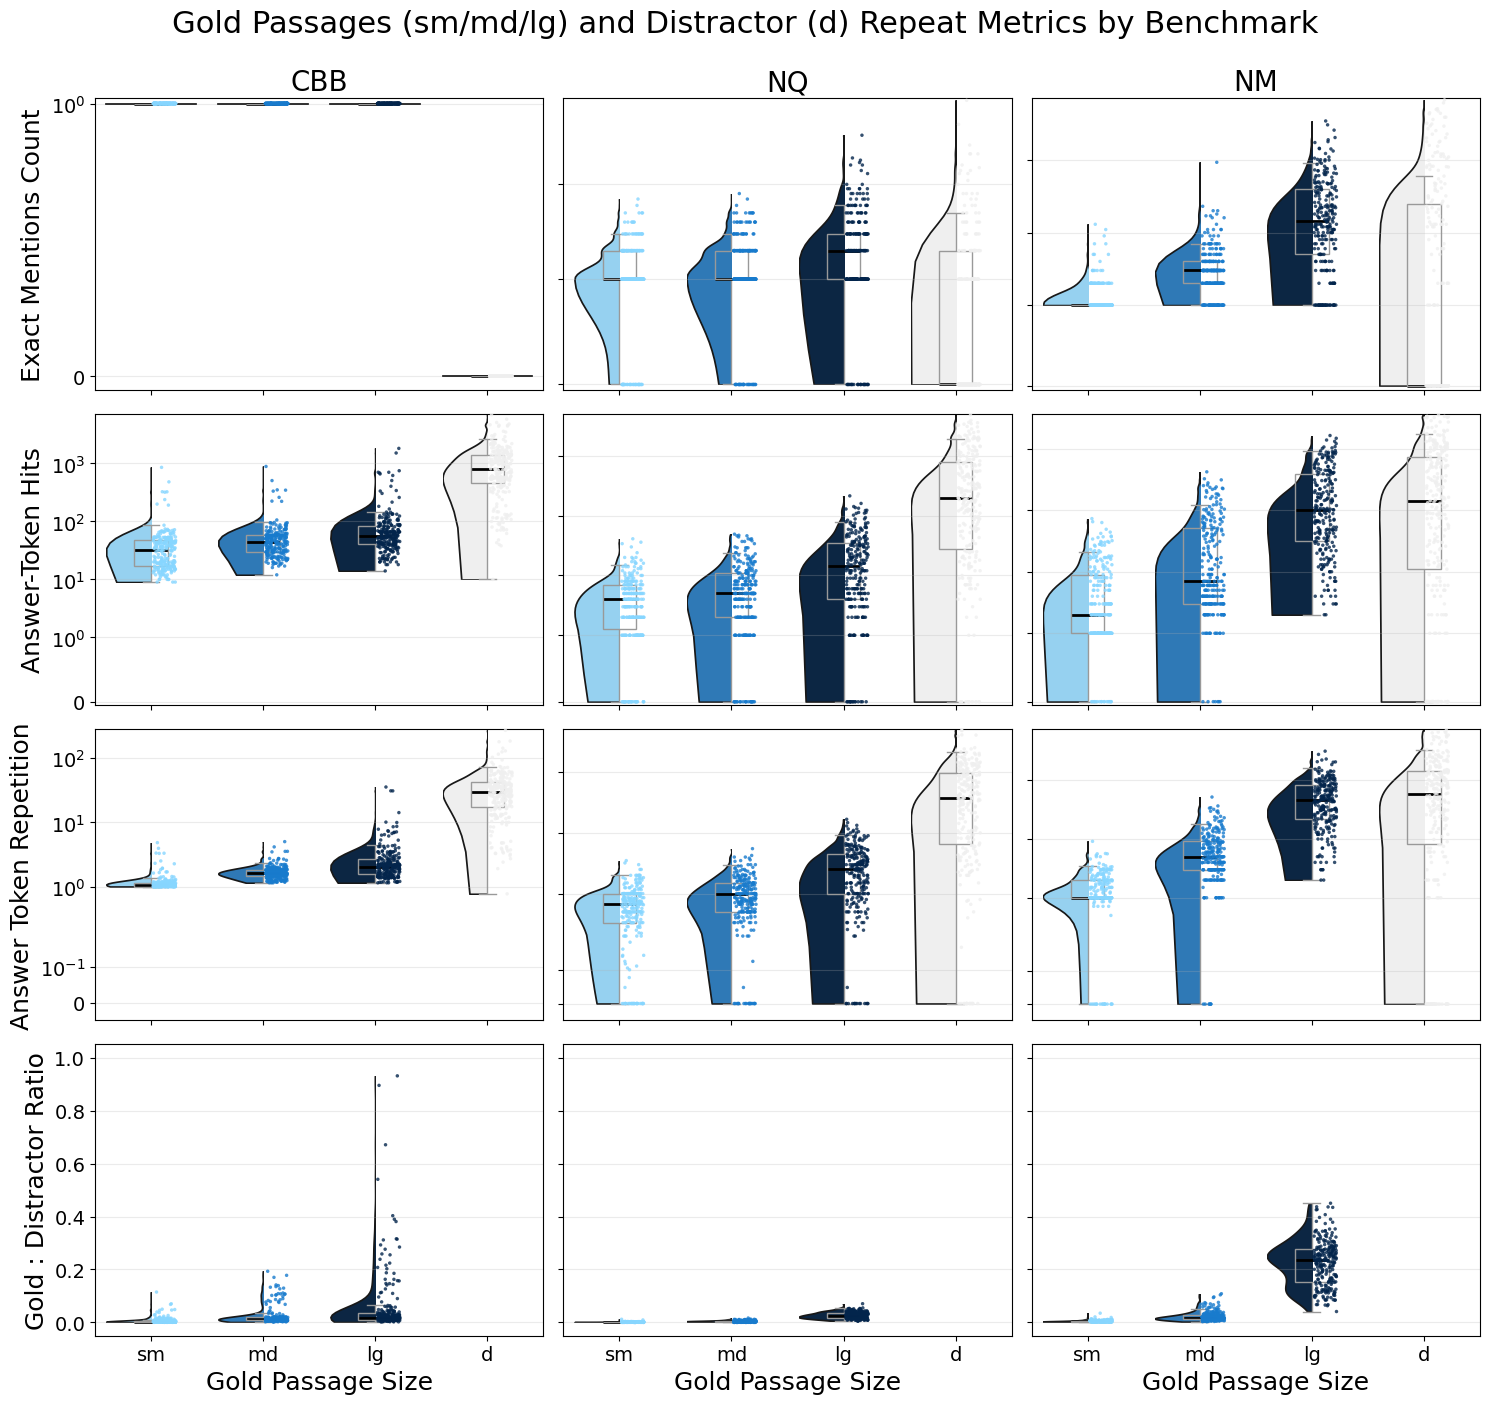

In [50]:
# Raincloud runner

def docs_long(df: pd.DataFrame, metric: str) -> pd.DataFrame:
    """
    Build a two-column DF [value, doc_type] from docs_fe table for the metric.
    """
    parts = []
    for stem, label in DOC_PREFIX.items():
        if label == "d" and metric == "to_d_ratio":
            continue
        col = f"{stem}_{metric}"
        if col in df.columns:
            parts.append(pd.DataFrame({metric: df[col], "doc_type": label}))
    return pd.concat(parts, ignore_index=True)

# grid of rainclouds
n_r, n_c = len(METRICS), len(BENCHMARK_DOCS_DFS_DICT)
fig, axes = plt.subplots(n_r, n_c, figsize=(5*n_c, 3.5*n_r), sharex="col")

for r, (metric, cfg) in enumerate(METRICS.items()):
    for c, (bench_name, docs_df) in enumerate(BENCHMARK_DOCS_DFS_DICT.items()):
        long_df = docs_long(docs_df, metric)
        long_df.attrs["benchmark"] = bench_name

        raincloud_by_goldsize(
            long_df,
            value_col=metric,
            gold_col="doc_type",
            order=ORDER,
            palette=PALETTE,
            ylabel=cfg["ylabel"] if c == 0 else "",
            scale=cfg["scale"],
            linthresh=cfg.get("linthresh", 1),
            ax=axes[r, c],
            show_stats=False,
            show_title=(r == 0),
        )

        if r == 0:
            axes[r, c].set_title(bench_name, fontsize=20)

for r in range(n_r):
    for c in range(1, n_c):
        axes[r, c].set_ylabel("")
        axes[r, c].set_yticklabels([])

fig.suptitle("Gold Passages (sm/md/lg) and Distractor (d) Repeat Metrics by Benchmark", y=1.0, fontsize=22)
plt.tight_layout()
plt.savefig("data/images/repetition.png")


### Binned Boxplots

In [27]:
# Binned Boxplots Helpers

def choose_bins(
    ser: pd.Series,
    *,
    min_unique: int = 2,
    max_bins: int = 5,
    quantile_bins: int | None = None
) -> pd.Series | pd.Categorical:
    ser = ser.dropna()

    if not np.issubdtype(ser.dtype, np.number):
        cats = sorted(ser.unique(), reverse=True)
        return pd.Series(pd.Categorical(ser, categories=cats, ordered=True), index=ser.index, name=ser.name)

    # small cardinality → single bin
    if ser.nunique() <= min_unique:
        return pd.Series(
            pd.Categorical(['all'] * len(ser), categories=['all']),
            index=ser.index,
            name=ser.name,
        )

    # quantile bins
    if quantile_bins and quantile_bins > 1:
        q = min(quantile_bins, ser.nunique())
        labels = [f"Q{i+1}" for i in range(q)]
        ranked = ser.rank(method="first")
        return pd.qcut(ranked, q=q, labels=labels)

    # equal‑width fallback
    k = min(max_bins, ser.nunique())
    labels = [f"B{i+1}" for i in range(k)]
    return pd.cut(ser, bins=k, labels=labels, include_lowest=True)

def _binom_ci_halfwidth(p: np.ndarray, n: np.ndarray, z: float = 1.96) -> np.ndarray:
    """Half width of a confidence interval for a proportion."""
    hw = np.sqrt(p * (1.0 - p) / np.maximum(n, 1)) * z
    hw[n == 0] = np.nan
    return hw


def plot_binned_accuracy_grouped(
    df: pd.DataFrame,
    feature: str,
    *,
    gold_col: str = "gold_size",
    order = ORDER,
    palette = PALETTE,
    quantile_bins: int | None = None,
    max_bins: int | None = None,
    ax: plt.Axes | None = None,
    width: float = 0.8,
    ref_lines: dict | None = None,
    error_bars: bool = True,
    ci: float = 0.95,
    bar_shrink: float = 0.9,
    show_missing: bool = True,
):
    """
    Grouped bar chart of accuracy by *feature* bins.
    """

    if "correct" not in df.columns:
        raise KeyError("'correct' column missing")

    # choose bins & prep dataframe
    bins = choose_bins(df[feature], quantile_bins=quantile_bins, max_bins=max_bins)
    df_tmp = df.assign(_bin=bins)

    # accuracy and counts matrices
    acc = (
        df_tmp.groupby(["_bin", gold_col], observed=True)["correct"].mean()
        .unstack(fill_value=np.nan)
        .reindex(index=bins.cat.categories, columns=order)
    )
    counts = (
        df_tmp.groupby(["_bin", gold_col], observed=True)["correct"].size()
        .unstack(fill_value=0)
        .reindex(index=bins.cat.categories, columns=order)
    )

    # compute CI half‑widths
    if error_bars:
        z = 1.96 if ci == 0.95 else np.sqrt(2) * abs(np.math.erfinv(ci))
        errs = _binom_ci_halfwidth(acc.values, counts.values, z)
        errors = pd.DataFrame(errs, index=acc.index, columns=acc.columns)
    else:
        errors = pd.DataFrame(np.zeros_like(acc.values), index=acc.index, columns=acc.columns)

    # plotting boilerplate
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 4))

    n_sizes = len(order)
    x_centers = np.arange(len(acc))

    slot = width / n_sizes
    bar_w = slot * bar_shrink
    offsets = (np.arange(n_sizes) - (n_sizes - 1) / 2) * slot

    legends_done = set()
    for idx, bin_label in enumerate(acc.index):
        for j, cat in enumerate(order):
            height = acc.at[bin_label, cat]
            n = counts.at[bin_label, cat]

            if np.isnan(height):
                if not show_missing:
                    continue
                height = 0.0
                err = 0.0
                facecolor = "none"
                edgecolor = "black"
                hatch = "//"
            else:
                err = errors.at[bin_label, cat] if error_bars else None
                facecolor = palette[j]
                edgecolor = "black"
                hatch = None

            bar = ax.bar(
                x_centers[idx] + offsets[j],
                height,
                width=bar_w,
                yerr=err,
                capsize=3 if error_bars and not np.isnan(height) else 0,
                error_kw=dict(lw=0.8, capthick=0.8),
                label=cat if cat not in legends_done else None,
                color=facecolor,
                edgecolor=edgecolor,
                hatch=hatch,
                zorder=2,
            )
            legends_done.add(cat)

    # reference lines
    if ref_lines:
        for lbl, d in ref_lines.items():
            ax.axhline(d["avg"], ls="--", lw=1.0, color=d["color"], label=f"{lbl} avg", zorder=3)

    # cosmetics
    ax.grid(True, axis="y", ls="--", lw=0.5, zorder=1)
    ax.set_xticks(x_centers)
    ax.set_xticklabels(acc.index.astype(str), rotation=45, ha="right", fontsize=11)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Accuracy", fontsize=13)
    ax.tick_params(axis="y", labelsize=11)
    ax.set_xlabel(feature, fontsize=13)
    mode = f"{quantile_bins}-quantile" if quantile_bins else "equal width"
    ax.set_title(f"Accuracy by {feature} ({mode} bins), grouped by {gold_col}", fontsize=14)
    ax.legend(title=gold_col, bbox_to_anchor=(1.02, 1), loc="upper left", title_fontsize=12, fontsize=11)
    ax.margins(x=0.01)
    plt.tight_layout()

    return ax

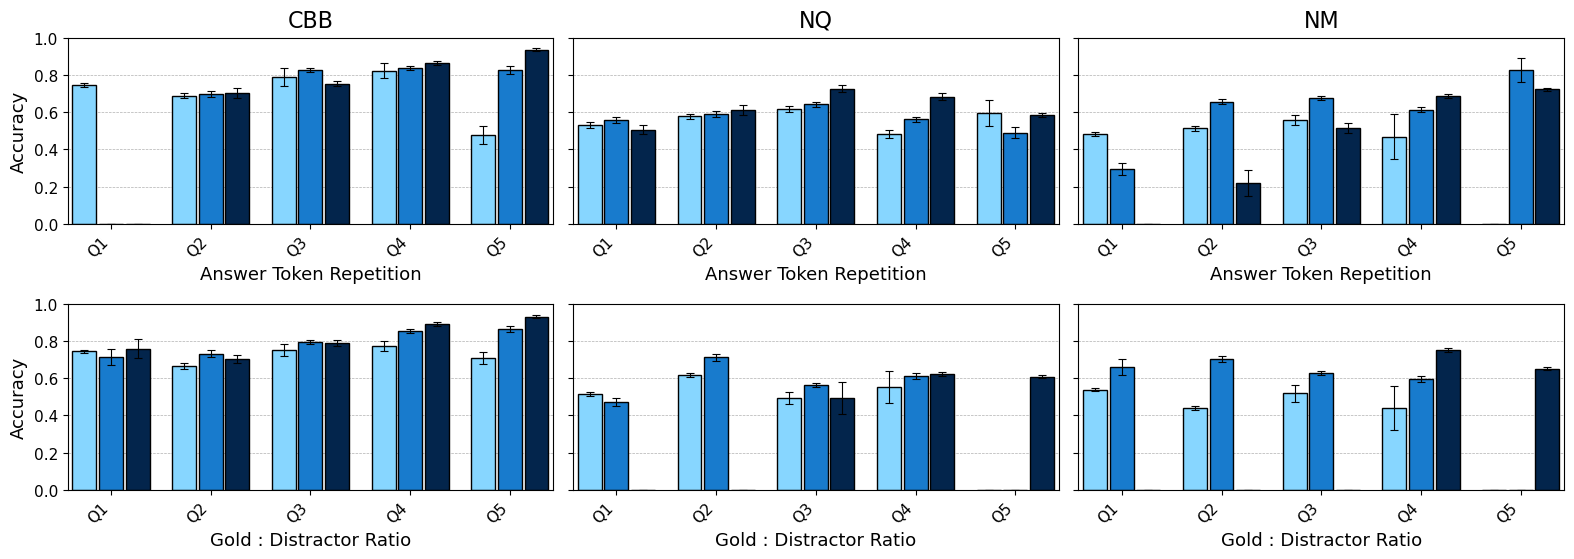

In [47]:

# Binned Boxplots Runner
FEATURE_LABELS = {
    "exact_mentions": "Exact Mentions",
    "ans_tok_redundancy": "Answer Token Repetition",
    "g_to_d_ratio": "Gold : Distractor Ratio"
}

METRICS = [
    # "exact_mentions",
    # "ans_tok_hits",
    # "ans_tok_hit_ratio",
    # "ans_tok_density",
    "ans_tok_redundancy",
    "g_to_d_ratio",
    # "g_to_all_ratio",
]
ORDER = list(DOC_PREFIX.values())
ORDER.remove("d")
ORDER = tuple(ORDER)

n_r, n_c = len(METRICS), len(BENCHMARK_DFS_DICT)

fig, axes = plt.subplots(
    nrows=n_r,
    ncols=n_c,
    figsize=(6 * n_c, 3.0 * n_r),
    sharey=True,
    squeeze=False,
    constrained_layout=False
)

for r, metric in enumerate(METRICS):
    for c, (bench_name, df) in enumerate(BENCHMARK_DFS_DICT.items()):
        size_means = df.groupby("gold_size", observed=True)["correct"].mean()
        ref_dict   = {lbl: {"avg": v, "color": DOC_COLORS[lbl]} for lbl, v in size_means.items()}

        ax = axes[r, c]

        plot_binned_accuracy_grouped(
            df,
            feature=metric,
            gold_col="gold_size",
            order=ORDER,
            palette=PALETTE,
            ax=ax,
            quantile_bins=5,
            # max_bins=4,
            # ref_lines=ref_dict,
        )

        # titles & y‑labels
        ax.set_title(bench_name if r == 0 else "", fontsize=16, pad=8)
        ax.set_ylabel(f"Accuracy" if c == 0 else "")
        ax.set_xlabel(FEATURE_LABELS.get(metric, metric))
        ax.legend_.remove()

# single, global legend to the right
handles, labels = axes[0, 0].get_legend_handles_labels()
# fig.legend(handles, labels, title="", loc="upper right", frameon=False, bbox_to_anchor=(.925, 0.625))
plt.tight_layout(rect=[0, 0.05, 0.88, 1])
# fig.suptitle("Accuracy by Confounder Features", x=0.46, y=1.03, fontsize=18)

plt.savefig("data/images/confounder_perf.png")
plt.show()

### Stats

In [29]:
import pandas as pd
from scipy.stats import binom
import numpy as np

def compute_accuracy_with_ci(df, condition=None, group_col='gold_size', target_col='correct'):
    if condition:
        df = df.query(condition)

    grouped = df.groupby(group_col)[target_col].agg(['sum', 'count']).rename(columns={'sum': 'correct', 'count': 'total'})

    grouped['accuracy'] = grouped['correct'] / grouped['total']
    
    z = 1.96
    n = grouped['total']
    p = grouped['accuracy']
    denom = 1 + z**2 / n
    centre = p + z**2 / (2 * n)
    adj = z * np.sqrt((p * (1 - p) + z**2 / (4 * n)) / n)
    
    grouped['ci_lower'] = (centre - adj) / denom
    grouped['ci_upper'] = (centre + adj) / denom

    return grouped[['accuracy', 'ci_lower', 'ci_upper', 'total']]

def filter_tasks_where_all_rows_match(df, condition_col, condition_val):
    # Identify task_ids where all rows meet the condition
    valid_task_ids = (
        df.groupby('task_id')[condition_col]
        .apply(lambda x: (x == condition_val).all())
    )
    # Keep only task_ids where the condition holds for all rows
    valid_task_ids = valid_task_ids[valid_task_ids].index
    return df[df['task_id'].isin(valid_task_ids)]

def filter_tasks_where_all_rows_match_condition(df, condition_col, condition_fn):
    # Identify task_ids where all rows satisfy the condition_fn
    valid_task_ids = (
        df.groupby('task_id')[condition_col]
        .apply(lambda x: condition_fn(x).all())
    )
    valid_task_ids = valid_task_ids[valid_task_ids].index
    return df[df['task_id'].isin(valid_task_ids)]

# models * questions * positions
11 * 250 * 5

13750

In [30]:
pd.options.display.float_format = '{:.2f}'.format

sizes = ["sm", "md", "lg"]
metric = "ans_tok_redundancy"
thresh = "<= 2.0"

for c, (bench_name, df) in enumerate(BENCHMARK_DFS_DICT.items()):
    filtered_df = filter_tasks_where_all_rows_match_condition(df, metric, lambda x: x <= 2.0)
    
    filtered_df = filtered_df[~((filtered_df["model"] == "Phi-4-reasoning") & (filtered_df["task_id"] > 183))]
    
    print(len(filtered_df['task_id'].unique()))
    result_df = compute_accuracy_with_ci(filtered_df)
    print("ALL ROWS", bench_name, metric, thresh)
    display(result_df)

122
ALL ROWS CBB ans_tok_redundancy <= 2.0


,accuracy,ci_lower,ci_upper,total
gold_size,,,,
lg,0.78,0.77,0.79,6555
md,0.73,0.72,0.74,6555
sm,0.64,0.63,0.65,6555


110
ALL ROWS NQ ans_tok_redundancy <= 2.0


,accuracy,ci_lower,ci_upper,total
gold_size,,,,
lg,0.65,0.64,0.67,7128
md,0.63,0.62,0.65,7128
sm,0.61,0.60,0.62,7128


2
ALL ROWS NM ans_tok_redundancy <= 2.0


,accuracy,ci_lower,ci_upper,total
gold_size,,,,
lg,0.22,0.16,0.30,132
md,0.05,0.02,0.10,132
sm,0.10,0.06,0.16,132


In [31]:
pd.options.display.float_format = '{:.2f}'.format

sizes = ["sm", "md", "lg"]
thresh = "ans_tok_redundancy<=2.0"

for c, (bench_name, df) in enumerate(BENCHMARK_DFS_DICT.items()):
    df = df[~((df["model"] == "Phi-4-reasoning") & (df["task_id"] > 183))]
    result_df = compute_accuracy_with_ci(df, thresh)
    print("INDIVIDUAL ROWS", bench_name, thresh)
    display(result_df)

INDIVIDUAL ROWS CBB ans_tok_redundancy<=2.0


,accuracy,ci_lower,ci_upper,total
gold_size,,,,
lg,0.78,0.77,0.79,6555
md,0.80,0.79,0.81,11965
sm,0.72,0.72,0.73,12985


INDIVIDUAL ROWS NQ ans_tok_redundancy<=2.0


,accuracy,ci_lower,ci_upper,total
gold_size,,,,
lg,0.65,0.64,0.67,7128
md,0.59,0.58,0.59,14226
sm,0.56,0.55,0.57,15774


INDIVIDUAL ROWS NM ans_tok_redundancy<=2.0


,accuracy,ci_lower,ci_upper,total
gold_size,,,,
lg,0.22,0.16,0.30,132
md,0.55,0.53,0.56,2862
sm,0.49,0.49,0.50,12708


In [32]:
pd.options.display.float_format = '{:.2f}'.format

sizes = ["sm", "md", "lg"]
model = "Gemini-2.0-Flash"
thresh = 'exact_mentions'

for c, (bench_name, df) in enumerate(BENCHMARK_DFS_DICT.items()):
    filtered_df = filter_tasks_where_all_rows_match(df, 'exact_mentions', 1)
    filtered_df = filtered_df[filtered_df['model'] == model]
    result_df = compute_accuracy_with_ci(filtered_df)
    print(bench_name, model, thresh)
    display(result_df)

CBB Gemini-2.0-Flash exact_mentions


,accuracy,ci_lower,ci_upper,total
gold_size,,,,
lg,0.73,0.71,0.76,1250
md,0.62,0.60,0.65,1250
sm,0.48,0.45,0.50,1250


NQ Gemini-2.0-Flash exact_mentions


,accuracy,ci_lower,ci_upper,total
gold_size,,,,
lg,0.60,0.55,0.64,504
md,0.60,0.55,0.64,504
sm,0.55,0.51,0.59,504


NM Gemini-2.0-Flash exact_mentions


,accuracy,ci_lower,ci_upper,total
gold_size,,,,
lg,0.83,0.77,0.88,186
md,0.68,0.61,0.74,186
sm,0.48,0.41,0.56,186


## Logistic Regressions

In [33]:
pd.set_option('display.float_format', '{:.4f}'.format)

In [34]:
# Helpers

correct_var = 'correct'

size_var = 'C(gold_size, Treatment(reference="sm"))'
ratio_var = 'g_to_d_ratio_scaled'
repeat_var = 'ans_tok_redundancy'
position_var = 'C(position, Treatment(reference="0.0"))'
model_var = 'C(model, Treatment(reference="LLaMA-3.1-8b"))'

In [35]:
# CBB
cbb_experimental = cbb[cbb["ans_tok_redundancy"] >= 2.0]
# Single variable models
cbb_logstic_size = smf.logit(f'{correct_var} ~ {size_var}', data=cbb).fit()
cbb_logstic_ratio = smf.logit(f'{correct_var} ~ {ratio_var}', data=cbb).fit()
cbb_logistic_repeat = smf.logit(f'{correct_var} ~ {repeat_var}', data=cbb).fit()
cbb_logistic_position = smf.logit(f'{correct_var} ~ {position_var}', data=cbb).fit()
cbb_logistic_model = smf.logit(f'{correct_var} ~ {model_var}', data=cbb).fit()

# Multivariable models
cbb_logistic_all = smf.logit(f'{correct_var} ~ {size_var} + {ratio_var} + {repeat_var} + {position_var}', data=cbb_experimental).fit()

# Model dict
cbb_models = {0:cbb_logstic_size, 1:cbb_logstic_ratio, 2:cbb_logistic_repeat, 3:cbb_logistic_position, 4:cbb_logistic_model, -1:cbb_logistic_all}

print(cbb_models[-1].summary())

Optimization terminated successfully.
         Current function value: 0.492483
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.497350
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.498689
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.495649
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.418836
         Iterations 8
Optimization terminated successfully.
         Current function value: 0.294725
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                correct   No. Observations:                10065
Model:                          Logit   Df Residuals:                    10056
Method:                           MLE   Df Model:                            8
Date:                Thu, 25 Sep 2025   Pseudo R-squ.:                  

In [36]:
# NQ
nq_experimental = nq[nq["ans_tok_redundancy"] >= 2.0]
# Single variable models
nq_logstic_size = smf.logit(f'{correct_var} ~ {size_var}', data=nq).fit()
nq_logstic_ratio = smf.logit(f'{correct_var} ~ {ratio_var}', data=nq).fit()
nq_logistic_repeat = smf.logit(f'{correct_var} ~ {repeat_var}', data=nq).fit()
nq_logistic_position = smf.logit(f'{correct_var} ~ {position_var}', data=nq).fit()
nq_logistic_model = smf.logit(f'{correct_var} ~ {model_var}', data=nq).fit()

# Multivariable models
nq_logistic_all = smf.logit(f'{correct_var} ~ {size_var} + {ratio_var} + {repeat_var} + {position_var}', data=nq_experimental).fit()

# Model dict
nq_models = {0:nq_logstic_size, 1:nq_logstic_ratio, 2:nq_logistic_repeat, 3:nq_logistic_position, 4:nq_logistic_model, -1:nq_logistic_all}

print(nq_models[-1].summary())

Optimization terminated successfully.
         Current function value: 0.677398
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.677513
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.678252
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.672554
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.636520
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.670848
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                correct   No. Observations:                13002
Model:                          Logit   Df Residuals:                    12992
Method:                           MLE   Df Model:                            9
Date:                Thu, 25 Sep 2025   Pseudo R-squ.:                 0

In [37]:
# NM
nm_experimental = nm[nm["ans_tok_redundancy"] >= 2.0]
# Single variable models
nm_logstic_size = smf.logit(f'{correct_var} ~ {size_var}', data=nm).fit()
nm_logstic_ratio = smf.logit(f'{correct_var} ~ {ratio_var}', data=nm).fit()
nm_logistic_repeat = smf.logit(f'{correct_var} ~ {repeat_var}', data=nm).fit()
nm_logistic_position = smf.logit(f'{correct_var} ~ {position_var}', data=nm).fit()
nm_logistic_model = smf.logit(f'{correct_var} ~ {model_var}', data=nm).fit()

# Multivariable models
nm_logistic_all = smf.logit(f'{correct_var} ~ {size_var} + {ratio_var} + {repeat_var} + {position_var}', data=nm_experimental).fit()

# Model dict
nm_models = {0:nm_logstic_size, 1:nm_logstic_ratio, 2:nm_logistic_repeat, 3:nm_logistic_position, 4:nm_logistic_model, -1:nm_logistic_all}

print(nm_models[-1].summary())

Optimization terminated successfully.
         Current function value: 0.654882
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.664703
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.662048
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.660445
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.586553
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.627146
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                correct   No. Observations:                36234
Model:                          Logit   Df Residuals:                    36224
Method:                           MLE   Df Model:                            9
Date:                Thu, 25 Sep 2025   Pseudo R-squ.:                 0

# Old

In [38]:
# # Violin‑box helper

# def violin_by_goldsize(
#     df,
#     *,
#     value_col: str,
#     ylabel: str | None = None,
#     gold_col: str = "gold_size",
#     order: tuple = ("sm", "md", "lg"),
#     palette: tuple = ("#87d6ff", "#187bcd", "#03254c"),
#     scale: str = "symlog",
#     linthresh: float = 1.0,
#     ax=None,
#     show_stats: bool = False,
# ):
#     """Violin + boxplot of a numeric metric split by gold size."""
#     lvls = [lvl for lvl in order if lvl in df[gold_col].unique()]
#     if not lvls:
#         raise ValueError(f"No {gold_col} levels found.")
#     pal = dict(zip(lvls, palette[: len(lvls)]))

#     plot_df = (
#         df[[value_col, gold_col]]
#         .dropna()
#         .query(f"{value_col} >= 0")
#         .assign(**{gold_col: pd.Categorical(df[gold_col], order, True)})
#     )

#     if ax is None:
#         _, ax = plt.subplots(figsize=(4, 3))

#     sns.violinplot(
#         data=plot_df,
#         x=gold_col, y=value_col,
#         order=lvls, hue=gold_col, palette=pal,
#         cut=0, inner=None, legend=False, ax=ax,
#     )
#     sns.boxplot(
#         data=plot_df,
#         x=gold_col, y=value_col,
#         order=lvls, width=.25, color="white",
#         showcaps=True,
#         boxprops={"facecolor": "white", "zorder": 3},
#         medianprops={"color": "k", "linewidth": 2},
#         ax=ax,
#     )

#     ax.set_yscale(scale, linthresh=linthresh) if scale == "symlog" else ax.set_yscale(scale)
#     ax.grid(axis="y", alpha=.25)

#     ax.set_xlabel("Gold passage size")
#     ax.set_ylabel(ylabel or value_col)
#     ax.set_title(df.attrs.get("benchmark", ""))

#     if show_stats:
#         summary = (plot_df.groupby(gold_col, observed=True)[value_col]
#                    .describe()[["count", "50%", "25%", "75%"]]
#                    .rename(columns={"50%": "median", "25%": "q1", "75%": "q3"}))
#         print(df.attrs.get("benchmark", ""))
#         display(summary)

#     return ax

In [39]:
# # Binned Boxplots Helpers

# def plot_binned_accuracy_stacked(
#     df: pd.DataFrame,
#     feature: str,
#     *,
#     gold_col: str = "gold_size",
#     order = ORDER,
#     palette = PALETTE,
#     quantile_bins: int | None = None,
#     max_bins: int | None = None,
#     ax: plt.Axes | None = None,
#     width: float = 0.8,
#     ref_lines: dict = None,
# ):
#     if "correct" not in df.columns:
#         raise KeyError("'correct' column missing")

#     # pick bins
#     bins = choose_bins(df[feature], quantile_bins=quantile_bins, max_bins=max_bins)

#     # accuracy per bin
#     df_tmp = df.assign(_bin=bins)
#     acc = df_tmp.groupby("_bin", observed=True)["correct"].mean().reindex(bins.cat.categories)
#     total = df_tmp.groupby("_bin", observed=True)["correct"].size()

#     # class composition per bin
#     counts = (
#         df_tmp.groupby(["_bin", gold_col], observed=True)[gold_col]
#         .size()
#         .unstack(fill_value=0)
#         .reindex(index=bins.cat.categories, columns=order, fill_value=0)
#         # .reindex(columns=order)
#         # .loc[acc.index]
#     )
#     prop = counts.div(counts.sum(axis=1), axis=0)
#     seg_h = prop.mul(acc.fillna(0), axis=0)

#     # plot
#     if ax is None:
#         _, ax = plt.subplots(figsize=(10, 4))

#     x = np.arange(len(acc))
#     bottom = np.zeros_like(acc.values, dtype=float)
#     for cat, color in zip(order, palette):
#         heights = seg_h[cat].values
#         ax.bar(
#             x,
#             heights,
#             bottom=bottom,
#             width=width,
#             label=cat,
#             color=color,
#             edgecolor="black",
#             zorder=2
#         )
#         bottom += heights
    
#     if ref_lines:
#         for lbl, d in ref_lines.items():
#             ax.axhline(d["avg"], ls="--", lw=1.0, color=d["color"], label=f"{lbl} avg", zorder=3)

#     ax.grid(True, axis="y", ls="--", lw=0.5, zorder=1)
#     ax.set_xticks(x)
#     ax.set_xticklabels(acc.index.astype(str), rotation=45, ha="right")
#     ax.set_ylim(0, 1)
#     ax.set_ylabel("Overall accuracy")
#     ax.set_xlabel(feature)
#     mode = f"{quantile_bins}-quantile" if quantile_bins else "equal width"
#     title = f"Accuracy by {feature} ({mode} bins), stacked by {gold_col} mix"
#     ax.set_title(title)
#     ax.set_title(title)
#     ax.legend(title=gold_col, bbox_to_anchor=(1.02, 1), loc="upper left")
#     ax.margins(x=0.01)
#     plt.tight_layout()
#     return ax

<!-- def binned_accuracy_stats(
    df: pd.DataFrame,
    feature: str,
    *,
    gold_col: str = "gold_size",
    quantile_bins: int | None = None,
    max_bins: int | None = None,
    ci: float = 0.95,
    keep_edges: bool = True,
    benchmark_name: str | None = None,
) -> pd.DataFrame:
    """
    Return a tidy DataFrame with one row per bin x gold_size  (optionally tagged with benchmark_name)

    Columns
    -------
    metric         str   -> feature name you passed in
    benchmark      str   -> optional
    bin            str   -> label (e.g. Q3, B1, (‑0.5,3.2])
    left, right    float -> numeric edges (omit if keep_edges=False)
    category       str   -> gold_size value
    n              int   -> sample size
    accuracy       float
    ci_low         float
    ci_high        float
    """
    # --- bin the feature -------------------------------------------------
    bins = choose_bins(
        df[feature],
        quantile_bins=quantile_bins,
        max_bins=max_bins,
    )
    df_tmp = df.assign(_bin=bins)

    # --- aggregate -------------------------------------------------------
    acc = (
        df_tmp.groupby(["_bin", gold_col], observed=True)["correct"]
        .mean()
        .unstack(fill_value=np.nan)
    )
    counts = (
        df_tmp.groupby(["_bin", gold_col], observed=True)["correct"]
        .size()
        .unstack(fill_value=0)
    )

    # CI half‑widths
    z = 1.96 if ci == 0.95 else np.sqrt(2) * abs(np.math.erfinv(ci))
    errs = _binom_ci_halfwidth(acc.values, counts.values, z)
    errors = pd.DataFrame(errs, index=acc.index, columns=acc.columns)

    # --- flatten to tidy -------------------------------------------------
    tidy = (
        pd.concat({'accuracy': acc, 'n': counts, 'err': errors}, axis=1)
        # gold_size becomes rows
        .stack(level=1, future_stack=True)         # ← add future_stack=True
        .rename_axis(index=['bin', 'category'])
        .reset_index()
    )

    tidy["ci_low"]  = (tidy["accuracy"] - tidy["err"]).clip(lower=0)
    tidy["ci_high"] = (tidy["accuracy"] + tidy["err"]).clip(upper=1)
    tidy = tidy.drop(columns="err")

    # optional numeric edges
    if keep_edges:
        if isinstance(bins.dtype, pd.api.types.IntervalDtype):
            tidy["left"]  = tidy["bin"].apply(lambda iv: iv.left)
            tidy["right"] = tidy["bin"].apply(lambda iv: iv.right)
        else:  # labelled categories – compute edges post‑hoc
            edges = (
                df_tmp.groupby("_bin", observed=True)[feature]
                .agg(left="min", right="max")
                .reset_index()
            )
            tidy = tidy.merge(edges, left_on="bin", right_on="_bin").drop(columns="_bin")

    # metadata
    tidy.insert(0, "metric", feature)
    if benchmark_name is not None:
        tidy.insert(1, "benchmark", benchmark_name)

    return tidy[
        [c for c in ["metric", "benchmark", "bin", "left", "right",
                     "category", "n", "accuracy", "ci_low", "ci_high"]
         if c in tidy.columns]  # drop edges if keep_edges=False
    ]

all_stats = []

for metric in METRICS:
    for bench_name, df in BENCHMARK_DFS_DICT.items():
        stats = binned_accuracy_stats(
            df,
            feature=metric,
            gold_col="gold_size",
            quantile_bins=5,
            benchmark_name=bench_name,
        )
        all_stats.append(stats)

all_stats = pd.concat(all_stats, ignore_index=True) -->


In [40]:
# bin_avgs = (
#     all_stats
#     .groupby(["metric", "benchmark", "bin"], as_index=False)
#     .apply(lambda g: pd.Series({
#         "n_total"           : g["n"].sum(),
#         "acc_weighted_mean" : np.average(g["accuracy"], weights=g["n"]),
#         "acc_unweighted_mean": g["accuracy"].mean(),
#     }))
# )

In [41]:
# all_stats.columns
# display(all_stats[all_stats['metric'] == "g_to_d_ratio"])

In [42]:
# from pandas.api.types import IntervalDtype

# def binned_accuracy_stats(
#     df: pd.DataFrame,
#     feature: str,
#     *,
#     gold_col: str = "gold_size",
#     quantile_bins: int | None = None,
#     max_bins: int | None = None,
#     ci: float = 0.95,
#     keep_edges: bool = True,
#     benchmark_name: str | None = None,
#     add_overall: bool = True,
# ) -> pd.DataFrame:
#     """
#     One row per (bin × gold_size).
#     Adds pooled 'overall' accuracy/CIs per bin if add_overall=True.
#     """
#     # ── bin the feature ────────────────────────────────────────────────
#     bins = choose_bins(df[feature], quantile_bins=quantile_bins, max_bins=max_bins)
#     df_tmp = df.assign(_bin=bins)

#     # ── per‑category accuracy & counts ────────────────────────────────
#     acc = (df_tmp.groupby(["_bin", gold_col], observed=True)["correct"]
#                  .mean().unstack(fill_value=np.nan))
#     counts = (df_tmp.groupby(["_bin", gold_col], observed=True)["correct"]
#                     .size().unstack(fill_value=0))

#     # 95 % (or given) CI half‑widths
#     z = 1.96 if ci == 0.95 else np.sqrt(2) * abs(np.math.erfinv(ci))
#     errs = _binom_ci_halfwidth(acc.values, counts.values, z)
#     errors = pd.DataFrame(errs, index=acc.index, columns=acc.columns)

#     # ── flatten to tidy ───────────────────────────────────────────────
#     tidy = (pd.concat({"accuracy": acc, "n": counts, "err": errors}, axis=1)
#               .stack(level=1, future_stack=True)        # gold_size becomes rows
#               .rename_axis(index=["bin", "category"])
#               .reset_index())

#     tidy["ci_low"]  = (tidy["accuracy"] - tidy["err"]).clip(lower=0)
#     tidy["ci_high"] = (tidy["accuracy"] + tidy["err"]).clip(upper=1)
#     tidy = tidy.drop(columns="err")

#     # ── bin edges (optional) ──────────────────────────────────────────
#     if keep_edges:
#         if isinstance(bins.dtype, IntervalDtype):
#             tidy["left"]  = tidy["bin"].map(lambda iv: iv.left)
#             tidy["right"] = tidy["bin"].map(lambda iv: iv.right)
#         else:                           # post‑hoc min/max
#             edges = (df_tmp.groupby("_bin", observed=True)[feature]
#                            .agg(left="min", right="max").reset_index())
#             tidy = tidy.merge(edges, left_on="bin", right_on="_bin").drop(columns="_bin")

#     # ── pooled “overall” accuracy per bin (optional) ──────────────────
#     if add_overall:
#         overall = (tidy.assign(success=lambda g: g["accuracy"] * g["n"])
#                          .groupby("bin", observed=False, as_index=False)
#                          .agg(n_total=("n", "sum"),
#                               success_total=("success", "sum")))
#         overall["acc_overall"] = overall["success_total"] / overall["n_total"]
#         hw = _binom_ci_halfwidth(overall["acc_overall"].values,
#                                  overall["n_total"].values, z)
#         overall["ci_low_overall"]  = (overall["acc_overall"] - hw).clip(lower=0)
#         overall["ci_high_overall"] = (overall["acc_overall"] + hw).clip(upper=1)
#         overall = overall.drop(columns="success_total")
#         tidy = tidy.merge(overall, on="bin")

#     # ── metadata & column order ───────────────────────────────────────
#     tidy.insert(0, "metric", feature)
#     if benchmark_name is not None:
#         tidy.insert(1, "benchmark", benchmark_name)

#     col_order = ["metric", "benchmark", "bin", "left", "right",
#                  "category", "n", "accuracy", "ci_low", "ci_high",
#                  "acc_overall", "ci_low_overall", "ci_high_overall", "n_total"]

#     return tidy[[c for c in col_order if c in tidy.columns]]


In [43]:
# all_stats = []

# for metric in METRICS:
#     for bench_name, df in BENCHMARK_DFS_DICT.items():
#         stats = binned_accuracy_stats(
#             df,
#             feature=metric,
#             gold_col="gold_size",
#             quantile_bins=5,
#             benchmark_name=bench_name,
#         )
#         all_stats.append(stats)

# all_stats = pd.concat(all_stats, ignore_index=True)


In [44]:
# all_stats['pct'] = all_stats['n'] / all_stats['n_total']
# filtered = all_stats[(all_stats['metric'] == 'g_to_d_ratio') & (all_stats['benchmark'] == 'NM')]
# display(filtered)

In [45]:
# for _, row in filtered.iterrows():
#     print(row['bin'])
#     print(f"{row['acc_overall']:.4f} ({row['ci_low_overall']:.4f}, {row['ci_high_overall']:.4f})")

In [46]:
# for _, row in filtered.iterrows():
#     print(row['bin'])
#     print(row['category'])
#     print(f"{row['accuracy']:.4f} ({row['ci_low']:.4f}, {row['ci_high']:.4f})")